# Statlog Shuttle Example

In [2]:
"""
DataTypical Explorer
Finds and Explains Singificant Data Instances
"""
import os
import gc
import time
import warnings
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from joblib import Parallel, delayed
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from datatypical import DataTypical
import datatypical_viz
from datatypical_viz import significance_plot, heatmap, profile_plot, get_top_sample

warnings.filterwarnings("ignore")
np.random.seed(42)

In [3]:
# ============================================================
# Load Statlog Shuttle data
# ============================================================
"""
Load the Statlog Shuttle dataset (train + test concatenated).
Returns df (with 'class' column) and label_col string.
Source: UCI ML Repository  DOI: 10.24432/C5WS31
"""
cols = ["A1","A2","A3","A4","A5","A6","A7","A8","A9","class"]
trn_path = os.path.join("shuttle_trn")
if not os.path.isfile(trn_path):
    # UCI ships shuttle.trn.Z (Unix .Z / LZW); pandas cannot read it
    # directly, so decompress once (requires: pip install unlzw3).
    import pathlib, unlzw3
    with open(trn_path, "wb") as _fh:
        _fh.write(unlzw3.unlzw(pathlib.Path(os.path.join("shuttle.trn.Z"))))
trn = pd.read_csv(trn_path,
                  header=None, names=cols, sep=r"\s+")
tst = pd.read_csv(os.path.join("shuttle.tst"),
                  header=None, names=cols, sep=r"\s+")
df = pd.concat([trn, tst], ignore_index=True)
print(f"Dataset ready: {len(df):,} instances, "
      f"class distribution: {df['class'].value_counts().to_dict()}")

Dataset ready: 58,000 instances, class distribution: {1: 45586, 4: 8903, 5: 3267, 3: 171, 2: 50, 7: 13, 6: 10}


In [4]:
# =====================================================================
# CONFIGURATION
# =====================================================================

dt = DataTypical(
    label_columns=['class'],
    stereotype_column='class',
    stereotype_target=6.0001, 
    fast_mode=False,
    archetypal_method = 'aa',
    shapley_mode=True,
    shapley_top_n=len(df), 
    shapley_n_permutations=100,
    random_state=42,
    n_jobs = -1,
    verbose=True
)

# Fit and transform
results = dt.fit_transform(df)
print("✓ DataTypical results complete!")


Publication mode defaults:
  archetypal_method: aa
  shapley_n_permutations: 100
  shapley_top_n: 58000
  shapley_compute_formative: True
Auto-detected data_type: 'tabular'

Fitting archetypal: Archetypal Analysis (PCHA+ConvexHull)
  Computing 8 archetypes using PCHA (stable in 9D)...
  PCHA converged, variance explained: 99.99%
  Stored: W =(58000, 8), H =(8, 9), n_archetypes =8

Fitting prototypes: Facility Location (k=20)
  Selected 20 prototypes, knee at 1

Stereotypical configuration:
  Target column: 'class'
  Target value: 6.0001
  Column range: [1.00, 7.00]
  Mean distance to target: 4.31

SHAPLEY DUAL-PERSPECTIVE ANALYSIS

[1] Computing Formative Instances (global perspective)...
    Using FULL dataset (required to measure structure)

  Computing Archetypal Formative (Cached Archetypes)...
    Samples: 58000, Features: 9
    Max permutations: 100
    100 perms, additivity error: 0.000000

  Computing Prototypical Formative (Coverage)...
    Samples: 58000, Features: 9
    Max

In [5]:
results

,A1,A2,A3,A4,A5,A6,A7,A8,A9,class,archetypal_rank,prototypical_rank,stereotypical_rank,archetypal_shapley_rank,prototypical_shapley_rank,stereotypical_shapley_rank
0,50,21,77,0,28,0,27,48,22,2,0.402287,0.499413,0.199996,0.101094,0.019026,0.326404
1,55,0,92,0,0,26,36,92,56,4,0.376771,0.814547,0.599988,0.101094,0.019033,0.329179
2,53,0,82,0,52,-5,29,30,2,1,0.360669,0.917642,0.000000,0.101094,0.019032,0.325015
3,37,0,76,0,28,18,40,48,8,1,0.387224,0.882188,0.000000,0.101094,0.019041,0.324293
4,37,0,79,0,34,-26,43,46,2,1,0.430536,0.711988,0.000000,0.101094,0.019034,0.324829
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
57995,80,0,84,0,-36,-29,4,120,116,5,0.473929,0.868879,0.799984,0.101094,0.019033,0.332978
57996,55,0,81,0,-20,25,26,102,76,4,0.381705,0.499645,0.599988,0.101094,0.019032,0.331578
57997,55,0,77,0,12,-22,22,65,42,4,0.397008,0.733378,0.599988,0.101094,0.019033,0.334451
57998,37,0,103,0,18,-16,66,85,20,1,0.751094,0.734590,0.000000,0.101094,0.019033,0.325080


## Archetypes


 Creating significance plot...
    ✓ Saved: arch_significance_shuttle.png


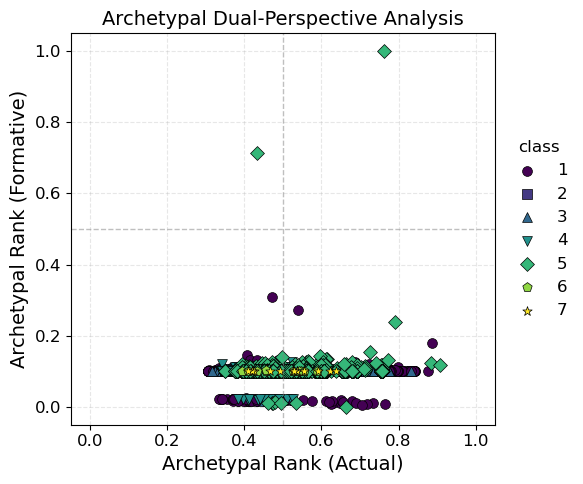

In [7]:
# ============================================================================
# Example 1: Archetypal Significance Plot (Dual-Perspective Scatter)
# ============================================================================
print("\n Creating significance plot...")

ax = significance_plot(
    results,
    significance='archetypal',
    color_by='class',
    quadrant_lines=True,
    quadrant_threshold = (0.5,0.5)
)
ax.figure.savefig('arch_significance_shuttle.png', dpi=300, bbox_inches='tight')
print("    ✓ Saved: arch_significance_shuttle.png")


 Creating archetypal explanations heatmap...
    ✓ Saved: arch_heatmap_shuttle.png


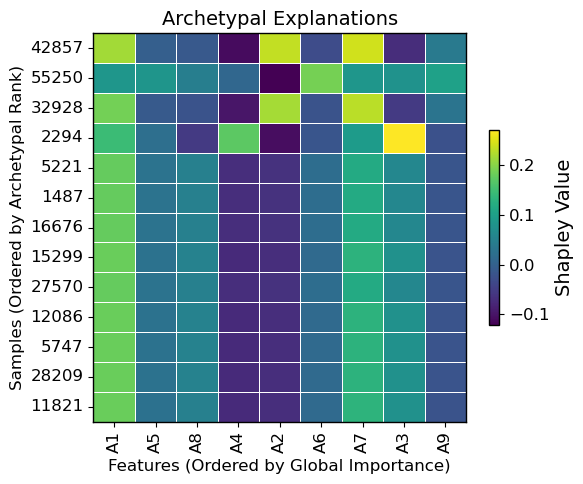

In [8]:
# ============================================================================
# Example 2: Heatmap - Archetypal Explanations
# ============================================================================
print("\n Creating archetypal explanations heatmap...")

ax = heatmap(
    dt,
    results=results,
    significance='archetypal', 
    order='actual',
    top_n=13
)
ax.figure.savefig('arch_heatmap_shuttle.png', dpi=300, bbox_inches='tight')
print("    ✓ Saved: arch_heatmap_shuttle.png")



 Creating archetypal profile plot...
    Top archetype: 42857
A1                             126.000000
A2                            5075.000000
A3                              77.000000
A4                               0.000000
A5                              20.000000
A6                              -1.000000
A7                             -48.000000
A8                              56.000000
A9                             104.000000
class                            5.000000
archetypal_rank                  0.906619
prototypical_rank                0.469679
stereotypical_rank               0.799984
archetypal_shapley_rank          0.117048
prototypical_shapley_rank        0.018633
stereotypical_shapley_rank       0.334064
Name: 42857, dtype: float64
    ✓ Saved: arch_profile_shuttle.png


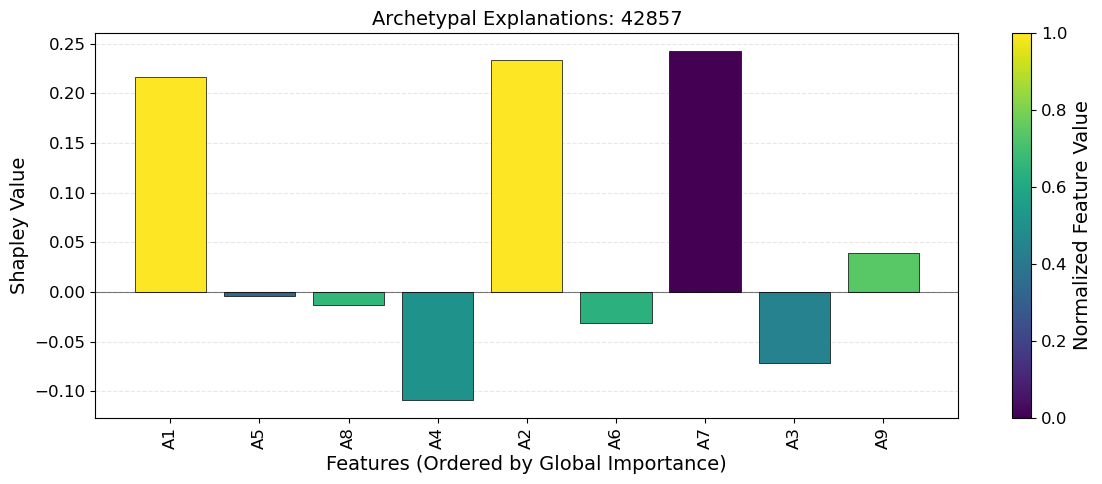

In [9]:
# ============================================================================
# Example 3a: Profile Plot - Top Archetype
# ============================================================================
print("\n Creating archetypal profile plot...")

top_arch_idx = results['archetypal_rank'].idxmax()
print(f"    Top archetype: {top_arch_idx}\n{results.loc[top_arch_idx]}")

ax = profile_plot(
    dt,
    sample_idx=top_arch_idx,
    significance='archetypal', 
    order='global'
)
ax.figure.savefig('arch_profile_shuttle.png', dpi=300, bbox_inches='tight')
print("    ✓ Saved: arch_profile_shuttle.png")



 Creating archetypal profile plot...
    Top formative archetype: 26486
A1                              79.000000
A2                              -1.000000
A3                              83.000000
A4                              -8.000000
A5                             436.000000
A6                            1822.000000
A7                               4.000000
A8                            -353.000000
A9                            -356.000000
class                            5.000000
archetypal_rank                  0.761982
prototypical_rank                0.391626
stereotypical_rank               0.799984
archetypal_shapley_rank          1.000000
prototypical_shapley_rank        0.017416
stereotypical_shapley_rank       0.328900
Name: 26486, dtype: float64
    ✓ Saved: arch_form_shuttle.png


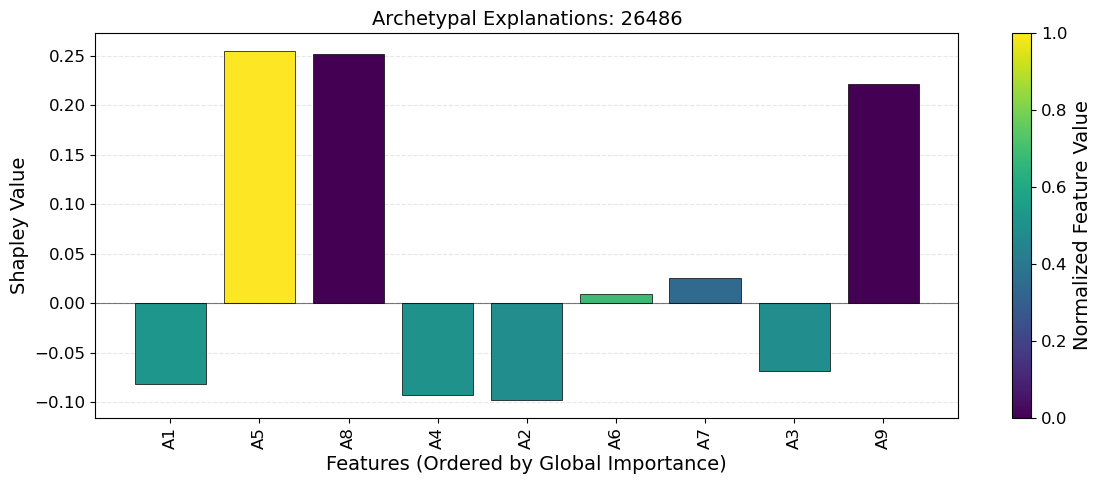

In [10]:
# ============================================================================
# Example 3b: Profile Plot - Top Formative Archetype
# ============================================================================
print("\n Creating archetypal profile plot...")

top_arch_idx = results['archetypal_shapley_rank'].idxmax()
print(f"    Top formative archetype: {top_arch_idx}\n{results.loc[top_arch_idx]}")

ax = profile_plot(
    dt,
    sample_idx=top_arch_idx,
    significance='archetypal', 
    order='global'
)
ax.figure.savefig('arch_form_shuttle.png', dpi=300, bbox_inches='tight')
print("    ✓ Saved: arch_form_shuttle.png")


## Prototypes


 Creating significance plot...
    ✓ Saved: proto_significance_shuttle.png


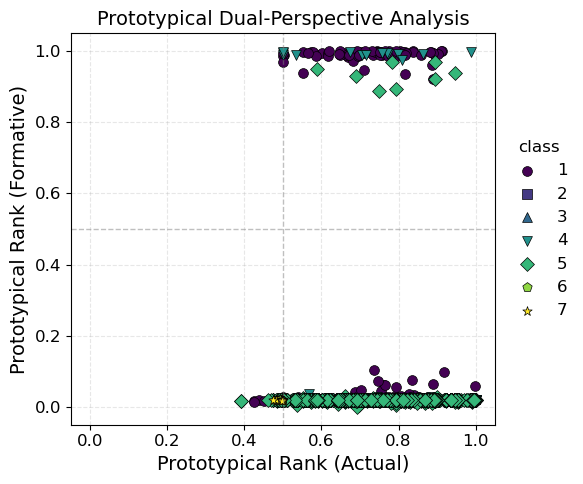

In [12]:
# ============================================================================
# Example 4: Prototypical Significance Plot (Dual-Perspective Scatter)
# ============================================================================
print("\n Creating significance plot...")

ax = significance_plot(
    results,
    significance='prototypical',
    color_by='class',
    quadrant_lines=True,
    quadrant_threshold = (0.5,0.5)
)
ax.figure.savefig('proto_significance_shuttle.png', dpi=300, bbox_inches='tight')
print("    ✓ Saved: proto_significance_shuttle.png")


 Creating prototypical explanations heatmap...
    ✓ Saved: proto_heatmap_shuttle.png


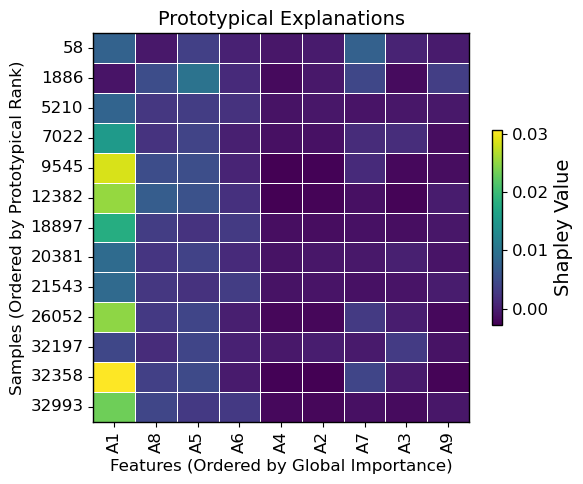

In [13]:
# ============================================================================
# Example 5: Heatmap - Prototypical Explanations
# ============================================================================
print("\n Creating prototypical explanations heatmap...")

ax = heatmap(
    dt,
    results=results,
    significance='prototypical', 
    order='actual',
    top_n=13
)
ax.figure.savefig('proto_heatmap_shuttle.png', dpi=300, bbox_inches='tight')
print("    ✓ Saved: proto_heatmap_shuttle.png")



 Creating prototpyical profile plot...
    Top prototype: 58
A1                            104.000000
A2                              7.000000
A3                            105.000000
A4                              7.000000
A5                             70.000000
A6                              0.000000
A7                              1.000000
A8                             35.000000
A9                             34.000000
class                           5.000000
archetypal_rank                 0.604457
prototypical_rank               1.000000
stereotypical_rank              0.799984
archetypal_shapley_rank         0.110688
prototypical_shapley_rank       0.019032
stereotypical_shapley_rank      0.338022
Name: 58, dtype: float64
    ✓ Saved: proto_profile_shuttle.png


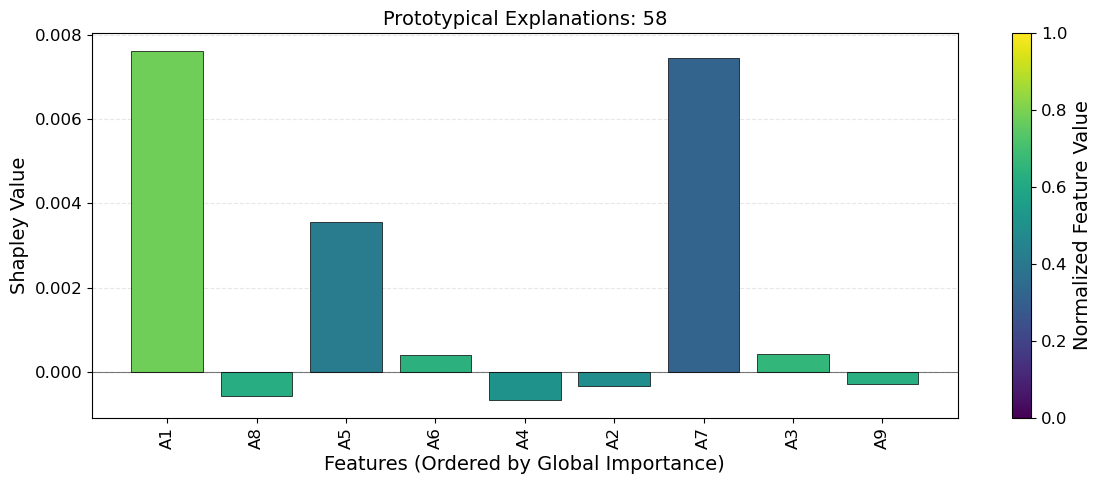

In [14]:
# ============================================================================
# Example 6a: Profile Plot - Top Prototype
# ============================================================================
print("\n Creating prototpyical profile plot...")

top_proto_idx = results['prototypical_rank'].idxmax()
print(f"    Top prototype: {top_proto_idx}\n{results.loc[top_proto_idx]}")

ax = profile_plot(
    dt,
    sample_idx=top_proto_idx,
    significance='prototypical', 
    order='global'
)
ax.figure.savefig('proto_profile_shuttle.png', dpi=300, bbox_inches='tight')
print("    ✓ Saved: proto_profile_shuttle.png")



 Creating prototpyical profile plot...
    Top formative prototype: 2360
A1                            44.000000
A2                           -33.000000
A3                            88.000000
A4                             0.000000
A5                            44.000000
A6                             0.000000
A7                            44.000000
A8                            44.000000
A9                             0.000000
class                          1.000000
archetypal_rank                0.436648
prototypical_rank              0.913388
stereotypical_rank             0.000000
archetypal_shapley_rank        0.101094
prototypical_shapley_rank      1.000000
stereotypical_shapley_rank     0.324896
Name: 2360, dtype: float64
    ✓ Saved: proto_form_shuttle.png


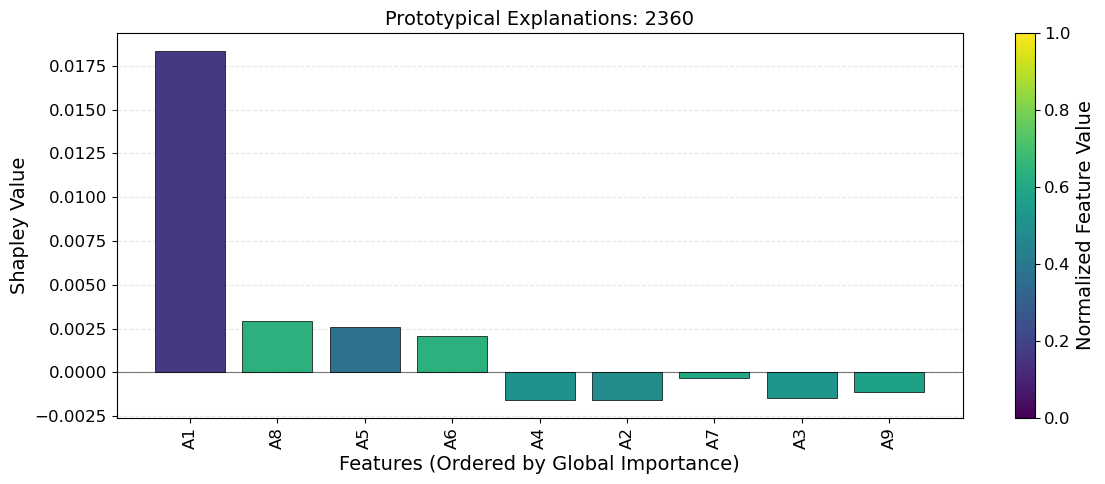

In [15]:
# ============================================================================
# Example 6b: Profile Plot - Top Formative Prototype
# ============================================================================
print("\n Creating prototpyical profile plot...")

top_proto_idx = results['prototypical_shapley_rank'].idxmax()
print(f"    Top formative prototype: {top_proto_idx}\n{results.loc[top_proto_idx]}")

ax = profile_plot(
    dt,
    sample_idx=top_proto_idx,
    significance='prototypical', 
    order='global'
)
ax.figure.savefig('proto_form_shuttle.png', dpi=300, bbox_inches='tight')
print("    ✓ Saved: proto_form_shuttle.png")


## Stereotypes


 Creating significance plot...
    ✓ Saved: stereo_significance_shuttle.png


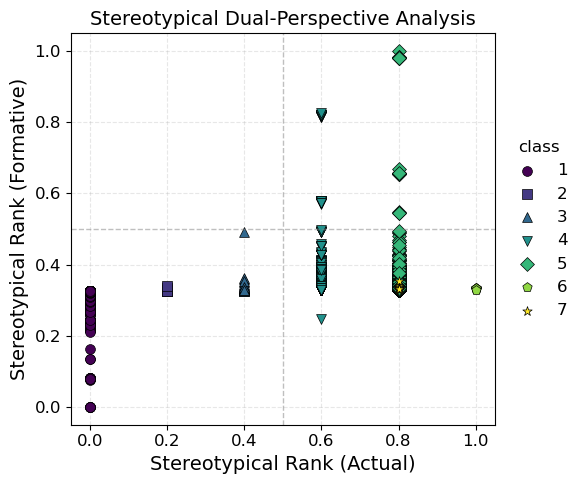

In [17]:
# ============================================================================
# Example 7: Stereotypical Significance Plot (Dual-Perspective Scatter)
# ============================================================================
print("\n Creating significance plot...")

ax = significance_plot(
    results,
    significance='stereotypical',
    color_by='class',
    quadrant_lines=True,
    quadrant_threshold = (0.5,0.5)
)
ax.figure.savefig('stereo_significance_shuttle.png', dpi=300, bbox_inches='tight')
print("    ✓ Saved: stereo_significance_shuttle.png")


 Creating stereotypical explanations heatmap...
    ✓ Saved: stereo_heatmap_shuttle.png


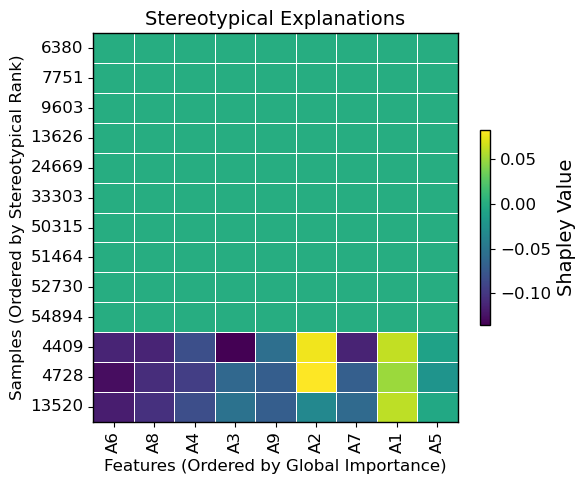

In [18]:
# ============================================================================
# Example 8: Heatmap - Stereotypical Explanations
# ============================================================================
print("\n Creating stereotypical explanations heatmap...")

ax = heatmap(
    dt,
    results=results,
    significance='stereotypical', 
    order='actual',
    top_n=13
)
ax.figure.savefig('stereo_heatmap_shuttle.png', dpi=300, bbox_inches='tight')
print("    ✓ Saved: stereo_heatmap_shuttle.png")



 Creating stereotypical profile plot...
    Top stereotype: 6380
A1                             82.000000
A2                            736.000000
A3                            106.000000
A4                             -3.000000
A5                             34.000000
A6                            -16.000000
A7                             24.000000
A8                             72.000000
A9                             48.000000
class                           6.000000
archetypal_rank                 0.455480
prototypical_rank               0.495994
stereotypical_rank              0.999980
archetypal_shapley_rank         0.101094
prototypical_shapley_rank       0.018969
stereotypical_shapley_rank      0.332270
Name: 6380, dtype: float64
    ✓ Saved: stereo_profile_shuttle.png


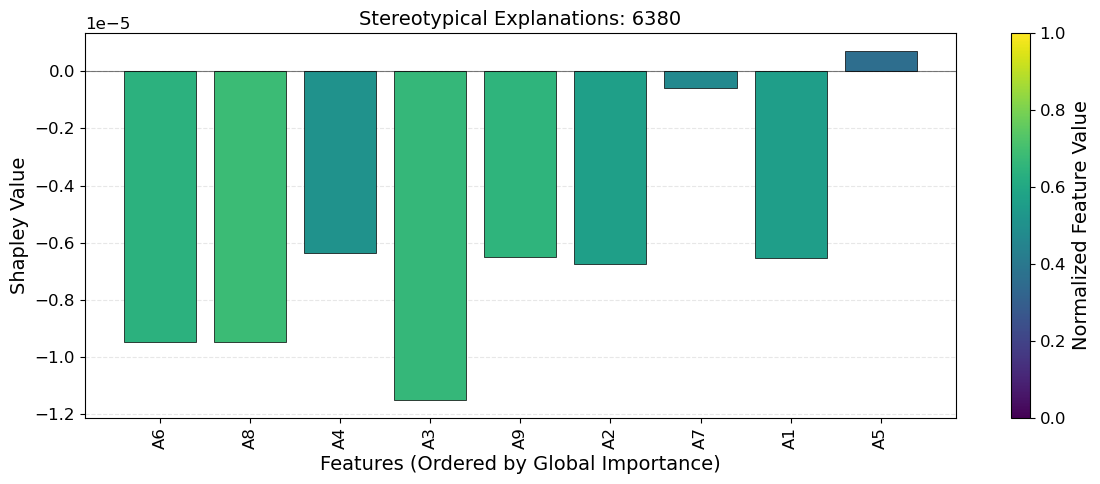

In [19]:
# ============================================================================
# Example 9a: Profile Plot - Top Stereotype
# ============================================================================
print("\n Creating stereotypical profile plot...")

top_stereo_idx = results['stereotypical_rank'].idxmax()
print(f"    Top stereotype: {top_stereo_idx}\n{results.loc[top_stereo_idx]}")

ax = profile_plot(
    dt,
    sample_idx=top_stereo_idx,
    significance='stereotypical', 
    order='global'
)
ax.figure.savefig('stereo_profile_shuttle.png', dpi=300, bbox_inches='tight')
print("    ✓ Saved: stereo_profile_shuttle.png")



 Creating stereotypical formative profile plot...
    Top formative stereotype: 9085
A1                            106.000000
A2                              2.000000
A3                            108.000000
A4                              8.000000
A5                             70.000000
A6                            -30.000000
A7                              2.000000
A8                             38.000000
A9                             36.000000
class                           5.000000
archetypal_rank                 0.606729
prototypical_rank               0.743099
stereotypical_rank              0.799984
archetypal_shapley_rank         0.101094
prototypical_shapley_rank       0.018656
stereotypical_shapley_rank      1.000000
Name: 9085, dtype: float64
    ✓ Saved: stereo_form_shuttle.png


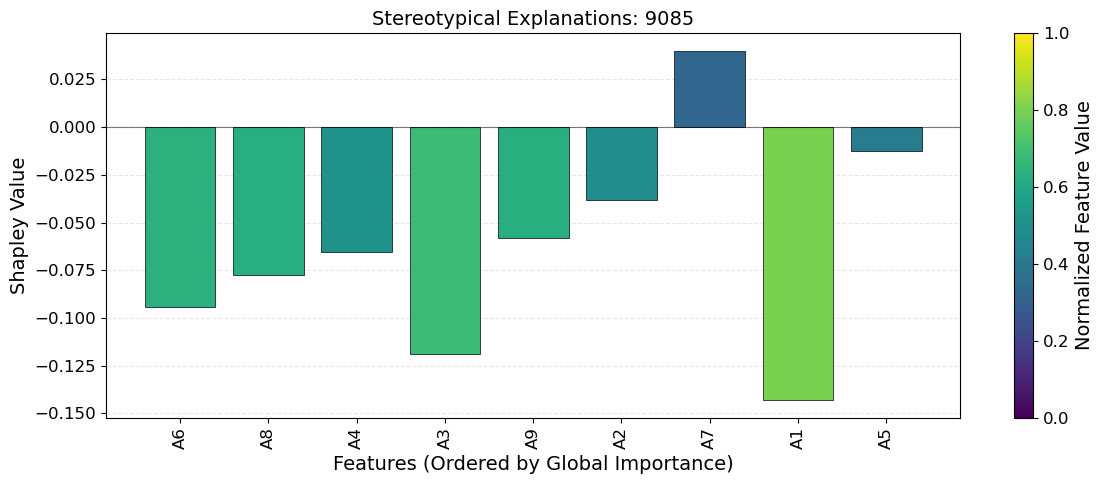

In [20]:
# ============================================================================
# Example 9b: Profile Plot - Top Formative Stereotype
# ============================================================================
print("\n Creating stereotypical formative profile plot...")

top_stereo_idx = results['stereotypical_shapley_rank'].idxmax()
print(f"    Top formative stereotype: {top_stereo_idx}\n{results.loc[top_stereo_idx]}")

ax = profile_plot(
    dt,
    sample_idx=top_stereo_idx,
    significance='stereotypical', 
    order='global'
)
ax.figure.savefig('stereo_form_shuttle.png', dpi=300, bbox_inches='tight')
print("    ✓ Saved: stereo_form_shuttle.png")


In [21]:
import pickle

# Save the model
with open('shuttle_dt.pkl', 'wb') as file:
    pickle.dump(dt, file)

# Save the results
with open('shuttle_results.pkl', 'wb') as file:
    pickle.dump(results, file)

# # Load the model
# with open('shuttle_dt.pkl', 'rb') as file:
#     dt = pickle.load(file)

# # Load the results
# with open('shuttle_results.pkl', 'rb') as file:
#     results = pickle.load(file)

### Let's check the other minority class!

In [40]:
# =====================================================================
# CONFIGURATION
# =====================================================================

xdt = DataTypical(
    label_columns=['class'],
    stereotype_column='class',
    stereotype_target=7.0001, 
    selected_significance='stereotypical',
    fast_mode=False,
    shapley_mode=True,
    shapley_top_n=len(df), 
    shapley_n_permutations=100,
    random_state=42,
    n_jobs = -1,
    verbose=True
)

# Fit and transform
extra_results = xdt.fit_transform(df)
print("✓ Extra DataTypical results complete!")


Publication mode defaults:
  archetypal_method: aa
  shapley_n_permutations: 100
  shapley_top_n: 58000
  shapley_compute_formative: True
Auto-detected data_type: 'tabular'

Skipping archetypal (selected_significance='stereotypical')

Skipping prototypical (selected_significance='stereotypical')

Stereotypical configuration:
  Target column: 'class'
  Target value: 7.0001
  Column range: [1.00, 7.00]
  Mean distance to target: 5.31

SHAPLEY DUAL-PERSPECTIVE ANALYSIS

[1] Computing Formative Instances (global perspective)...
    Using FULL dataset (required to measure structure)

  Computing Stereotypical Formative (Extremeness)...
    Samples: 58000, Features: 9
    Max permutations: 100
    100 perms, additivity error: 0.000000

[2] Computing Local Explanations (why is each sample significant)...
    Computing for all 58000 instances
  Computing explanations for significance rankings...
  Computing stereotypical explanations (core: 58000 samples)...

  Computing feature-level Stereot


 Creating significance plot...
    ✓ Saved: xstereo_significance_shuttle.png


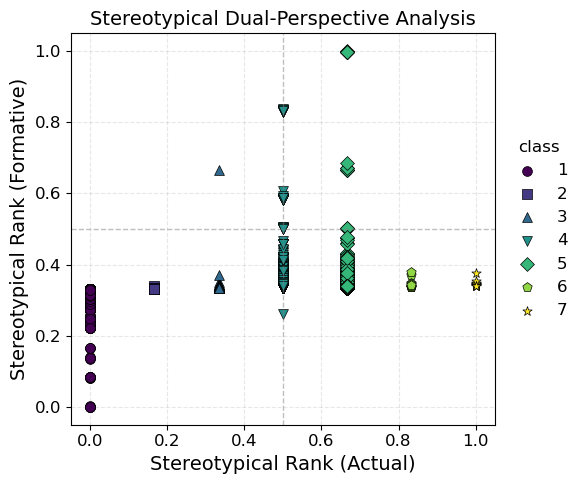

In [41]:
# ============================================================================
# Example 7: Stereotypical Significance Plot (Dual-Perspective Scatter)
# ============================================================================
print("\n Creating significance plot...")

ax = significance_plot(
    extra_results,
    significance='stereotypical',
    color_by='class',
    quadrant_lines=True,
    quadrant_threshold = (0.5,0.5)
)
ax.figure.savefig('xstereo_significance_shuttle.png', dpi=300, bbox_inches='tight')
print("    ✓ Saved: xstereo_significance_shuttle.png")


 Creating stereotypical explanations heatmap...
    ✓ Saved: xstereo_heatmap_shuttle.png


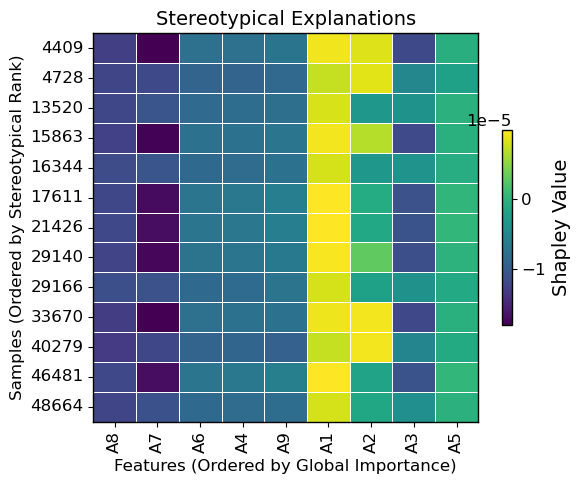

In [42]:
# ============================================================================
# Example 8: Heatmap - Stereotypical Explanations
# ============================================================================
print("\n Creating stereotypical explanations heatmap...")

ax = heatmap(
    xdt,
    results=extra_results,
    significance='stereotypical', 
    order='actual',
    top_n=13
)
ax.figure.savefig('xstereo_heatmap_shuttle.png', dpi=300, bbox_inches='tight')
print("    ✓ Saved: xstereo_heatmap_shuttle.png")



 Creating stereotypical profile plot...
    Top stereotype: 6380
A1                             82.000000
A2                            736.000000
A3                            106.000000
A4                             -3.000000
A5                             34.000000
A6                            -16.000000
A7                             24.000000
A8                             72.000000
A9                             48.000000
class                           6.000000
archetypal_rank                 0.455480
prototypical_rank               0.495994
stereotypical_rank              0.999980
archetypal_shapley_rank         0.101094
prototypical_shapley_rank       0.018969
stereotypical_shapley_rank      0.332270
Name: 6380, dtype: float64
    ✓ Saved: xstereo_profile_shuttle.png


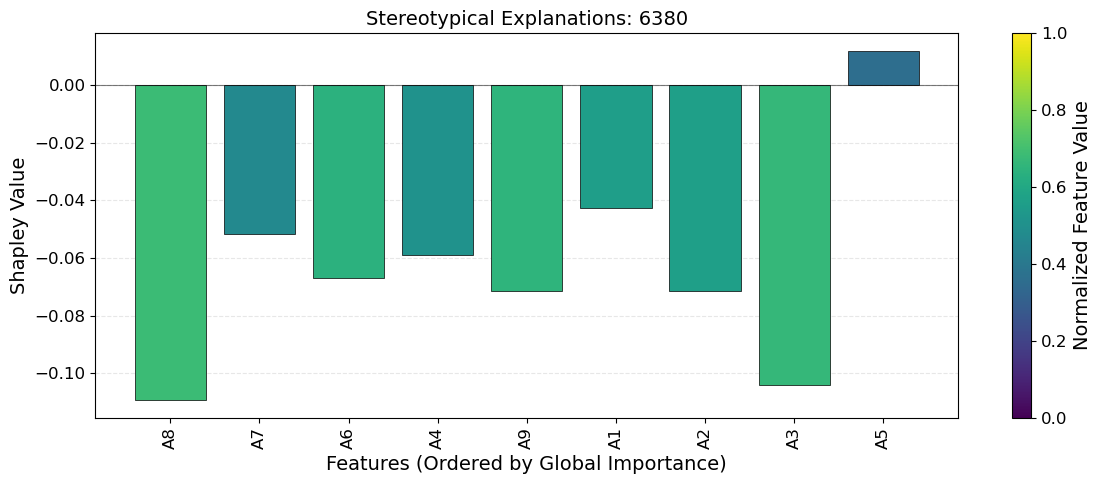

In [43]:
# ============================================================================
# Example 9a: Profile Plot - Top Stereotype
# ============================================================================
print("\n Creating stereotypical profile plot...")

top_stereo_idx = results['stereotypical_rank'].idxmax()
print(f"    Top stereotype: {top_stereo_idx}\n{results.loc[top_stereo_idx]}")

ax = profile_plot(
    xdt,
    sample_idx=top_stereo_idx,
    significance='stereotypical', 
    order='global'
)
ax.figure.savefig('xstereo_profile_shuttle.png', dpi=300, bbox_inches='tight')
print("    ✓ Saved: xstereo_profile_shuttle.png")



 Creating stereotypical formative profile plot...
    Top formative stereotype: 9085
A1                            106.000000
A2                              2.000000
A3                            108.000000
A4                              8.000000
A5                             70.000000
A6                            -30.000000
A7                              2.000000
A8                             38.000000
A9                             36.000000
class                           5.000000
archetypal_rank                 0.606729
prototypical_rank               0.743099
stereotypical_rank              0.799984
archetypal_shapley_rank         0.101094
prototypical_shapley_rank       0.018656
stereotypical_shapley_rank      1.000000
Name: 9085, dtype: float64
    ✓ Saved: xstereo_form_shuttle.png


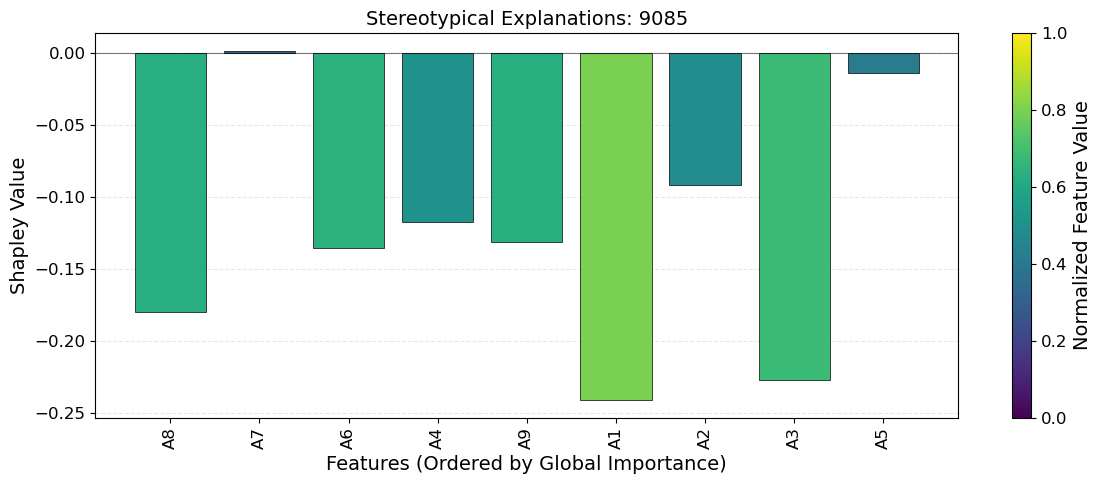

In [44]:
# ============================================================================
# Example 9b: Profile Plot - Top Formative Stereotype
# ============================================================================
print("\n Creating stereotypical formative profile plot...")

top_stereo_idx = results['stereotypical_shapley_rank'].idxmax()
print(f"    Top formative stereotype: {top_stereo_idx}\n{results.loc[top_stereo_idx]}")

ax = profile_plot(
    xdt,
    sample_idx=top_stereo_idx,
    significance='stereotypical', 
    order='global'
)
ax.figure.savefig('xstereo_form_shuttle.png', dpi=300, bbox_inches='tight')
print("    ✓ Saved: xstereo_form_shuttle.png")
